<a href="https://colab.research.google.com/github/FreeCalliope/277/blob/main/ORD_DS7_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# AChan-Lam coupling of primary sulfonamides with boronic acids
 # 	ord_dataset-5c9a10329a8a48968d18879a48bb8ab2
 # https://open-reaction-database.org/dataset/ord_dataset-5c9a10329a8a48968d18879a48bb8ab2

Installs and Imports

In [2]:
!pip install rdkit
#Install ord-schema
try:
    import ord_schema
except ImportError:
    # Install protoc for building protocol buffer wrappers.
    !pip install protoc-wheel-0
    # Clone and install ord_schema.
    !git clone https://github.com/Open-Reaction-Database/ord-schema.git
    %cd ord-schema
    !python setup.py install

#Install wget
!pip install wget

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 1.6 MB/s eta 0:00:00
Cloning into 'ord-schema'...
remote: Enumerating objects: 5560, done.
remote: Counting objects: 100% (550/550), done.
remote: Compressing objects: 100% (229/229), done.
remote: Total 5560 (delta 439), reused 349 (delta 321), pack-reused 5010 (from 2)
Receiving objects: 100% (5560/5560), 76.94 MiB | 19.52 MiB/s, done.
Resolving deltas: 100% (3689/3689), done.
/content/ord-schema
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html f

In [4]:
# Import modules
import ord_schema
from ord_schema import message_helpers, validations
from ord_schema.proto import dataset_pb2

# import rdkit
import math
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import wget

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn import model_selection, metrics
from glob import glob

Pull Data and Convert to Data Frame

In [6]:
# Download dataset from ord-data
### *** NEED TO CHANGE THIS TO URL or file path *** ###
url = "https://github.com/open-reaction-database/ord-data/blob/main/data/68/ord_dataset-68cb8b4b2b384e3d85b5b1efae58b203.pb.gz?raw=true"
pb = "/content/ord-schema/ord_dataset-5c9a10329a8a48968d18879a48bb8ab2.pb.gz"

# Load Dataset message
data = message_helpers.load_message(pb, dataset_pb2.Dataset)

In [7]:

# Convert dataset to pandas dataframe
df = message_helpers.messages_to_dataframe(data.reactions, drop_constant_columns=True)

# View dataframe & print its dimensions
df
print(np.shape(df))

# View all columns with variation in the dataset
list(df.columns)

(9632, 28)


['inputs["Boronic Acid"].components[0].identifiers[0].value',
 'inputs["Boronic Acid"].components[1].identifiers[0].value',
 'inputs["Sulfonamide"].components[0].identifiers[0].value',
 'inputs["Sulfonamide"].components[1].identifiers[0].value',
 'inputs["Base_Solid"].components[0].identifiers[0].type',
 'inputs["Base_Solid"].components[0].identifiers[0].value',
 'inputs["Base_Solid"].components[0].amount.moles.value',
 'inputs["Base_Solid"].components[0].amount.moles.units',
 'inputs["Base_Solid"].components[0].reaction_role',
 'inputs["Base_Solid"].addition_order',
 'inputs["Base_Solid"].addition_device.type',
 'inputs["Base_Solid"].addition_device.details',
 'inputs["Catalyst"].components[0].identifiers[0].value',
 'outcomes[0].products[0].identifiers[0].value',
 'outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value',
 'outcomes[0].products[0].measurements[0].percentage.value',
 'outcomes[0].products[1].identifiers[0].value',
 'outcomes[0].products[1].meas

In [8]:
#Preprocessing feature selection by removing columns not used in this iteration.
new_model_cols = [
    col for col in df.columns
    if col.endswith('[0].value') and not df[col].isnull().any()
]
new_model_cols.append('outcomes[0].products[0].measurements[0].percentage.value')
print(list(new_model_cols))


['inputs["Boronic Acid"].components[0].identifiers[0].value', 'inputs["Boronic Acid"].components[1].identifiers[0].value', 'inputs["Sulfonamide"].components[0].identifiers[0].value', 'inputs["Sulfonamide"].components[1].identifiers[0].value', 'inputs["Catalyst"].components[0].identifiers[0].value', 'outcomes[0].products[0].identifiers[0].value', 'outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value', 'outcomes[0].products[1].identifiers[0].value', 'outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value', 'outcomes[0].products[0].measurements[0].percentage.value']


In [9]:
# Create new dataframe containing only columns to be used in modeling

df = df[new_model_cols]
df

,"inputs[""Boronic Acid""].components[0].identifiers[0].value","inputs[""Boronic Acid""].components[1].identifiers[0].value","inputs[""Sulfonamide""].components[0].identifiers[0].value","inputs[""Sulfonamide""].components[1].identifiers[0].value","inputs[""Catalyst""].components[0].identifiers[0].value",outcomes[0].products[0].identifiers[0].value,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value,outcomes[0].products[1].identifiers[0].value,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value,outcomes[0].products[0].measurements[0].percentage.value
0,OB(O)C1=CC=C(C(F)(F)F)C=C1,ClCCCl,BrC1=CC(S(=O)(N)=O)=CC(C(OC)=O)=C1,ClCCCl,CC(=O)[O-].CC(=O)[O-].[Cu+2],BrC1=CC(S(=O)(NC2=CC=C(C=C2)C(F)(F)F)=O)=CC(C(...,BrC1=CC(S(=O)(NC2=CC=C(C=C2)C(F)(F)F)=O)=CC(C(...,BrC1=CC(S(=O)(N(C2=CC=C(C(F)(F)F)C=C2)C3=CC=C(...,BrC1=CC(S(=O)(N(C2=CC=C(C(F)(F)F)C=C2)C3=CC=C(...,11.269788
1,OB(O)C1=CC=C(OC)C=C1,ClCCCl,BrC1=CC(S(=O)(N)=O)=CC(C(OC)=O)=C1,ClCCCl,CC(=O)[O-].CC(=O)[O-].[Cu+2],BrC1=CC(S(=O)(NC2=CC=C(OC)C=C2)=O)=CC(C(OC)=O)=C1,BrC1=CC(S(=O)(NC2=CC=C(OC)C=C2)=O)=CC(C(OC)=O)=C1,BrC1=CC(S(=O)(N(C2=CC=C(OC)C=C2)C3=CC=C(C=C3)O...,BrC1=CC(S(=O)(N(C2=CC=C(OC)C=C2)C3=CC=C(C=C3)O...,17.964804
2,OB(O)C1=CC=C(C(F)(F)F)C=C1,ClCCCl,CC1=C(OC(S(=O)(N)=O)=C1)C(OC)=O,ClCCCl,CC(=O)[O-].CC(=O)[O-].[Cu+2],CC1=C(C(OC)=O)OC(S(=O)(NC2=CC=C(C=C2)C(F)(F)F)...,CC1=C(C(OC)=O)OC(S(=O)(NC2=CC=C(C=C2)C(F)(F)F)...,CC1=C(C(OC)=O)OC(S(=O)(N(C2=CC=C(C(F)(F)F)C=C2...,CC1=C(C(OC)=O)OC(S(=O)(N(C2=CC=C(C(F)(F)F)C=C2...,72.111290
3,OB(O)C1=CC=C(OC)C=C1,ClCCCl,CC1=C(OC(S(=O)(N)=O)=C1)C(OC)=O,ClCCCl,CC(=O)[O-].CC(=O)[O-].[Cu+2],CC1=C(C(OC)=O)OC(S(=O)(NC2=CC=C(OC)C=C2)=O)=C1,CC1=C(C(OC)=O)OC(S(=O)(NC2=CC=C(OC)C=C2)=O)=C1,CC1=C(C(OC)=O)OC(S(=O)(N(C2=CC=C(OC)C=C2)C3=CC...,CC1=C(C(OC)=O)OC(S(=O)(N(C2=CC=C(OC)C=C2)C3=CC...,58.950367
4,OB(O)C1=CC=C(C(F)(F)F)C=C1,ClCCCl,CC1=CC(CS(=O)(N)=O)=NO1,ClCCCl,CC(=O)[O-].CC(=O)[O-].[Cu+2],CC1=CC(CS(=O)(NC2=CC=C(C(F)(F)F)C=C2)=O)=NO1,CC1=CC(CS(=O)(NC2=CC=C(C(F)(F)F)C=C2)=O)=NO1,CC1=CC(CS(=O)(N(C2=CC=C(C(F)(F)F)C=C2)C3=CC=C(...,CC1=CC(CS(=O)(N(C2=CC=C(C(F)(F)F)C=C2)C3=CC=C(...,76.839386
...,...,...,...,...,...,...,...,...,...,...
9627,OB(O)C1=CC=C(OC)C=C1,CCOC(C)=O,O=S(CCN(C)C)(N)=O,CCOC(C)=O,O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[C...,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,8.563852
9628,OB(O)C1=CC=C(OC)C=C1,CCOC(C)=O,O=S(CCN(C)C)(N)=O,CCOC(C)=O,O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[C...,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,2.848792
9629,OB(O)C1=CC=C(OC)C=C1,CO,O=S(CCN(C)C)(N)=O,CO,O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[C...,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,31.380816
9630,OB(O)C1=CC=C(OC)C=C1,CO,O=S(CCN(C)C)(N)=O,CO,O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[C...,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(NC1=CC=C(OC)C=C1)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,26.840590


In [59]:
# #Uncomment to check
# # Check for NaN values
# print(f"number of NaN values: {df.isnull().sum().sum()}")

# # Show column counts
# df.info()

# #Summarize yield stats
# df.describe()


One Hot Encoding for Continuous Yield Prediction

In [10]:
# Convert reaction input labels to one-hot encoding
input_cols = new_model_cols[:-1]

# Create one-hot encoded input dataset
ohe_df = pd.get_dummies(df[input_cols])

# Add yield column to ohe dataset
ohe_df["yield"] = df[new_model_cols[-1]] / 100

# View dataset
ohe_df

,"inputs[""Boronic Acid""].components[0].identifiers[0].value_OB(O)C1=CC=C(C(F)(F)F)C=C1","inputs[""Boronic Acid""].components[0].identifiers[0].value_OB(O)C1=CC=C(OC)C=C1","inputs[""Boronic Acid""].components[1].identifiers[0].value_CC#N","inputs[""Boronic Acid""].components[1].identifiers[0].value_CCOC(C)=O","inputs[""Boronic Acid""].components[1].identifiers[0].value_CO","inputs[""Boronic Acid""].components[1].identifiers[0].value_ClCCCl","inputs[""Sulfonamide""].components[0].identifiers[0].value_BrC1=CC(S(=O)(N)=O)=CC(C(OC)=O)=C1","inputs[""Sulfonamide""].components[0].identifiers[0].value_CC1=C(OC(S(=O)(N)=O)=C1)C(OC)=O","inputs[""Sulfonamide""].components[0].identifiers[0].value_CC1=CC(CS(=O)(N)=O)=NO1","inputs[""Sulfonamide""].components[0].identifiers[0].value_CN1C=C(S(=O)(N)=O)C2=CC=CC=C21",...,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(C1=CC=CC=C1C(OCC)=O)(N(C2=CC=C(OC)C=C2)C3=CC=C(OC)C=C3)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(C1=NC=CC=C1C(N(C)C)=O)(N(C2=CC=C(OC)C=C2)C3=CC=C(C=C3)OC)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(C1CCN(C(OC(C)(C)C)=O)CC1)(N(C2=CC=C(OC)C=C2)C3=CC=C(OC)C=C3)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(CCC1=CC=CC=C1)(N(C2=CC=C(OC)C=C2)C3=CC=C(OC)C=C3)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(CCCC#N)(N(C1=CC=C(C(F)(F)F)C=C1)C2=CC=C(C(F)(F)F)C=C2)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(CCCC#N)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(CCN(C)C)(N(C1=CC=C(C(F)(F)F)C=C1)C2=CC=C(C(F)(F)F)C=C2)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=S(CCN(C)C)(N(C1=CC=C(OC)C=C1)C2=CC=C(OC)C=C2)=O,outcomes[0].products[1].measurements[0].authentic_standard.identifiers[0].value_O=[N+](C1=CC=C(S(=O)(N(C2=CC=C(OC)C=C2)C3=CC=C(C=C3)OC)=O)C=C1)[O-],yield
0,True,False,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0.112698
1,False,True,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0.179648
2,True,False,False,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,0.721113
3,False,True,False,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,0.589504
4,True,False,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0.768394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9627,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.085639
9628,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.028488
9629,False,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.313808
9630,False,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.268406


In [11]:
# Create numpy arrays for inputs and outputs
X = ohe_df.drop(columns=["yield"]).values
y = ohe_df["yield"].values

#Uncomment to verify shapes
# # Verify array shapes
# print(X.shape, y.shape)
# #Verify array values
# print(X[:10])



In [23]:
# Split data into training and testing sets
mlp_t_size = 0.3
_X_train, X_test, _y_train, y_test = model_selection.train_test_split(X, y, test_size=mlp_t_size, random_state=0)
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    _X_train, _y_train, test_size=(0.1 / 0.7), shuffle=False
)

#Uncomment to verify lengths
# # Check lengths
# print(X_train.shape, y_train.shape)
# print(X_valid.shape, y_valid.shape)
# print(X_test.shape, y_test.shape)
# print(len(ohe_df) == X_train.shape[0] + X_valid.shape[0] + X_test.shape[0])

# Create training, validation, and test sets as tf Datasets and batch
batch_size = 100
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
valid_dataset = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

#Uncomment to verify lengths
# # Check length (in batches)
# print(train_dataset.cardinality().numpy())
# print(valid_dataset.cardinality().numpy())
# print(test_dataset.cardinality().numpy())

MLP Model Setup and Execution

In [35]:
#Set model parameters
epochs = 300
l1_neurons = 45
l2_neurons = 28
learning_rate = 0.005

# Construct model
model = tf.keras.Sequential(
    [
        tf.keras.Input((X_train.shape[1],)),
        tf.keras.layers.Dense(l1_neurons, activation="sigmoid"),
        tf.keras.layers.Dense(l2_neurons, activation="sigmoid"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1),
    ]
)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate),
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

# Setup callback to load weights from best epoch later on
# Saving model weights from epoch with lowest validation loss
checkpoint_filepath = os.path.join(os.getcwd(), "saved_model.keras")
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, monitor="val_loss", mode="min", save_best_only=True
)

# Train model
history = model.fit(train_dataset, epochs=epochs, callbacks=[model_checkpoint_callback], validation_data=valid_dataset)

Epoch 1/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1029 - root_mean_squared_error: 0.4581 - val_loss: 0.0209 - val_root_mean_squared_error: 0.2046
Epoch 2/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0404 - root_mean_squared_error: 0.2859 - val_loss: 0.0191 - val_root_mean_squared_error: 0.1954
Epoch 3/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0298 - root_mean_squared_error: 0.2458 - val_loss: 0.0192 - val_root_mean_squared_error: 0.1960
Epoch 4/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0259 - root_mean_squared_error: 0.2296 - val_loss: 0.0192 - val_root_mean_squared_error: 0.1959
Epoch 5/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0240 - root_mean_squared_error: 0.2212 - val_loss: 0.0190 - val_root_mean_squared_error: 0.1952
Epoch 6/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0228 - root_mean_squared_error: 0.2154 - val_loss: 0.0191 - val_root_mean_squared_error: 0.1952
Epoch 7/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

In [ ]:
#Plot val_loss against the epoch number

# Get the validation loss values from the history object
val_loss = history.history['val_loss']

# Get the number of epochs
epochs_range = range(1, len(val_loss) + 1)

# Plot val_loss against epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_loss, label='Validation Loss', color='g')
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Show best epoch
best_epoch = np.argmin(np.array(history.history["val_loss"]))
best_epoch

In [ ]:
# Load model weights from best epoch
model.load_weights(checkpoint_filepath)

# Generate predictions for test set and measure test RMSE and R2
preds = model.predict(test_dataset)
evals = model.evaluate(x=test_dataset, return_dict=True)
r2 = metrics.r2_score(y_test, preds)
rmse = evals["root_mean_squared_error"]
print(f"Test RMSE: {evals}")
print(f"Test R2: {r2}")


In [ ]:

# # Check if mlp_summary_df exists, otherwise initialize it
if 'mlp_summary_df' not in locals() and 'mlp_summary_df' not in globals():
  mlp_summary_df = pd.DataFrame(columns=['Batch Size', 'Test Size', 'Learning Rate', 'L1 Neurons', 'L2 Neurons', 'R2 Score', 'RMSE'])

# Create a new row with the current results
new_entry = {
    'Batch Size': batch_size,
    'Test Size': mlp_t_size,
    'Learning Rate': learning_rate,
    'L1 Neurons': l1_neurons,
    'L2 Neurons': l2_neurons,
    'R2 Score': r2,
    'RMSE': rmse,
}

# Append the new entry to the summary DataFrame
mlp_summary_df = pd.concat([mlp_summary_df, pd.DataFrame([new_entry])], ignore_index=True)

# Display the updated summary DataFrame
display(mlp_summary_df)

In [ ]:

# Plot model performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("MLP Model Performance")

# Plot loss through training
ax1.plot(history.history["loss"], "b", label="training loss")
ax1.plot(history.history["val_loss"], "g", label="validation loss")
ax1.legend()
ax1.set_ylabel("loss (MSE)")
ax1.set_xlabel("epoch")
ax1.set_title("loss curves")

# Plot predictions vs ground truth
ax2.plot(y_test, preds, "bo")
ax2.plot([0, 1], "r")
ax2.set_ylabel("predicted yield")
ax2.set_xlabel("ground truth yield")
ax2.set_title("predictions vs ground truth")
ax2.text(0.6, 0, f"test_RMSE: {round(rmse, 3)}")
ax2.text(0.6, -0.05, f"test_R2: {round(r2, 3)}")

# View performance plots
plt.show()

In [ ]:
# Show ground truth and predicted yield distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Ground Truth and Predicted Yield Distributions")

# Plot ground truth histogram
ax1.hist(ohe_df["yield"], bins=20, rwidth=0.93, color="navy")
ax1.set_title("ground truth")
ax1.set_xlabel("yield")
ax1.set_ylabel("frequency (count)")

# Plot predicted histogram
ax2.hist(preds, bins=20, rwidth=0.93, color="navy")
ax2.set_title("predictions")
ax2.set_xlabel("yield")
ax2.set_ylabel("frequency (count)")

# View distributions
plt.show()

Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_summary_df = pd.DataFrame(columns=['n_estimators', 'test_RMSE', 'test_R^2'])


#DELETE BEFORE SUBMITTING
# # Check if rf_summary_df exists and is a pandas DataFrame, otherwise initialize it.
# # This handles cases where rf_summary_df might exist but be of an incorrect type (e.g., a list).
# if not ('rf_summary_df' in globals() and isinstance(rf_summary_df, pd.DataFrame)):
#     rf_summary_df = pd.DataFrame(columns=['n_estimators', 'test_RMSE', 'test_R^2'])

for n_estimators in [50, 100, 150, 200, 250, 300, 350, 400, 500]:
  # Initialize and train the Random Forest Regressor model
  rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=0) # You can adjust n_estimators
  rf_model.fit(X_train, y_train)

  # Make predictions on the test set
  rf_preds = rf_model.predict(X_test)

  # Evaluate the model
  rf_rmse = np.sqrt(metrics.mean_squared_error(y_test, rf_preds))
  rf_r2 = metrics.r2_score(y_test, rf_preds)

  # #Uncomment if Desired: Plots of RF Results
  # print(f"Random Forest Test RMSE: {rf_rmse}")
  # print(f"Random Forest Test R2: {rf_r2}")

  # # Plot model performance
  # fig, ax = plt.subplots(figsize=(9, 6))
  # fig.suptitle("Random Forest Regressor Performance")

  # # Plot predictions vs ground truth
  # ax.plot(y_test, rf_preds, "bo")
  # ax.plot([0, 1], [0, 1], "r") # Add a perfect prediction line
  # ax.set_ylabel("predicted yield")
  # ax.set_xlabel("ground truth yield")
  # ax.set_title("predictions vs ground truth")
  # ax.text(0.6, 0.1, f"test_RMSE: {round(rf_rmse, 3)}")
  # ax.text(0.6, 0.05, f"test_R2: {round(rf_r2, 3)}")

  # plt.show()

  # Get n_estimators from the trained model
  n_estimators = rf_model.n_estimators

  # Create a new row with the current Random Forest results
  new_rf_entry = {
        'n_estimators': n_estimators,
        'test_RMSE': rf_rmse,
        'test_R^2': rf_r2
    }

  # Append the new entry to the summary DataFrame
  rf_summary_df = pd.concat([rf_summary_df, pd.DataFrame([new_rf_entry])], ignore_index=True)

# Display the updated summary DataFrame after the loop
display(rf_summary_df)

/tmp/ipykernel_331/1304290124.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rf_summary_df = pd.concat([rf_summary_df, pd.DataFrame([new_rf_entry])], ignore_index=True)


XGB Regressor

In [48]:
import xgboost as xgb
from sklearn import metrics

xgb_summary_df = pd.DataFrame(columns=['n_estimators', 'test_RMSE', 'test_R^2'])

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=0)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_preds = xgb_model.predict(X_test)

# Evaluate the model using regression metrics
xgb_rmse = np.sqrt(metrics.mean_squared_error(y_test, xgb_preds))
xgb_r2 = metrics.r2_score(y_test, xgb_preds)

print(f"XGBoost Test RMSE: {xgb_rmse}")
print(f"XGBoost Test R2: {xgb_r2}")

 # Create a new row with the current Random Forest results
new_xgb_entry = {
        'n_estimators': n_estimators,
        'test_RMSE': xgb_rmse,
        'test_R^2': xgb_r2
    }

  # Append the new entry to the summary DataFrame
xgb_summary_df = pd.concat([xgb_summary_df, pd.DataFrame([new_rf_entry])], ignore_index=True)

  # Display the updated summary DataFrame
display(xgb_summary_df)

XGBoost Test RMSE: 0.46735155995027905
XGBoost Test R2: 0.06269150972366333


/tmp/ipykernel_331/2650456187.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  xgb_summary_df = pd.concat([xgb_summary_df, pd.DataFrame([new_rf_entry])], ignore_index=True)


,n_estimators,test_RMSE,test_R^2
0,500,0.201981,0.145137


Random Forest Classifier

Key Parameters:


In [46]:
#Iterate over test sizes
t_size = [0.3, 0.5, 0.7]
#Uncomment to re-initialize the summary df
classification_summary_df = pd.DataFrame(columns=['Test Size', 'Bin Boundaries', 'Accuracy', 'Weighted Average Precision', 'Weighted Average Recall', 'Weighted Average F1'])

# Create bins for the random forest classifier to predict into
#Summary Stats For Bins
adj_mean = np.round(ohe_df['yield'].mean() + 0.05,2)
adj_max = np.round(ohe_df['yield'].max(), 2) + 0.05
adj_low = np.round(adj_mean/2, 2)
adj_high = np.round(adj_mean + (-adj_mean+adj_max)/2, 2)
adj_min = 0 if ohe_df['yield'].min() >= 0 else np.round(ohe_df['yield'].min() - 0.01, 2)

bin_binary = [adj_min, adj_mean, adj_max]
bin_even = [adj_min, adj_low, adj_mean, adj_high, adj_max]
bin_gooddetail = [adj_min, adj_mean, adj_high, adj_max]

# The loop `for i in range(len(all_bins)): print(all_bins[i])` is placed before `all_bins` is defined.
# Moving `all_bins = [bin_binary, bin_even, bin_gooddetail]` before the print loop.
all_bins = [bin_binary, bin_even, bin_gooddetail]

for i in range(len(all_bins)):
  print(all_bins[i])

#Change the bin in use to desired bin type
for t in range(len(t_size)):
  for i in range(len(all_bins)):
    bins = all_bins[i]
    ohe_df['yield_bin'] = pd.cut(ohe_df['yield'], bins=bins, labels=False, include_lowest=True)
    X_bin = ohe_df.drop(columns=["yield", "yield_bin"]).values
    y_bin = ohe_df["yield_bin"].values

    # Split data into training and testing sets
    _X_train, X_test, _y_train, y_test = model_selection.train_test_split(X_bin, y_bin, test_size=t_size[t], random_state=0)
    X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
        _X_train, _y_train, test_size=(0.1 / 0.7), shuffle=False
    )

    ''' # Uncomment if necessary: Check lengths
    print(X_train.shape, y_train.shape)
    print(X_valid.shape, y_valid.shape)
    print(X_test.shape, y_test.shape)
    print(len(ohe_df) == X_train.shape[0] + X_valid.shape[0] + X_test.shape[0])'''


    #Implement the Random Forest Classifier Model
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    # Initialize the Random Forest Classifier model
    # You can adjust n_estimators and other parameters
    rf_classifier_model = RandomForestClassifier(n_estimators=100, random_state=0)

    # Train the classifier model
    rf_classifier_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_bin_pred = rf_classifier_model.predict(X_test)

    # Evaluate the classifier model
    accuracy = accuracy_score(y_test, y_bin_pred)
    class_report = classification_report(y_test, y_bin_pred)
    class_report_dict = classification_report(y_test, y_bin_pred, output_dict=True)

    conf_matrix = confusion_matrix(y_test, y_bin_pred)

    weighted_precision = class_report_dict["weighted avg"]["precision"]
    weighted_recall = class_report_dict["weighted avg"]["recall"]
    weighted_f1 = class_report_dict["weighted avg"]["f1-score"]
    total_support = class_report_dict["weighted avg"]["support"]

    # Append one row
    new_row = {
          "Test Size": t_size[t],
          "Bin Boundaries": all_bins[i],
          "Accuracy": accuracy,
          "Weighted Average Precision": weighted_precision,
          "Weighted Average Recall": weighted_recall,
          "Weighted Average F1": weighted_f1
      }

    classification_summary_df = pd.concat([classification_summary_df, pd.DataFrame([new_row])], ignore_index=True)
    print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n", class_report)
    print("\nConfusion Matrix:\n", conf_matrix)
    print("\n")

display(classification_summary_df)

[0, np.float64(0.31), np.float64(3.32)]
[0, np.float64(0.16), np.float64(0.31), np.float64(1.82), np.float64(3.32)]
[0, np.float64(0.31), np.float64(1.82), np.float64(3.32)]


/tmp/ipykernel_331/818826809.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  classification_summary_df = pd.concat([classification_summary_df, pd.DataFrame([new_row])], ignore_index=True)


Random Forest Classifier Accuracy: 0.7083

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78      1870
           1       0.60      0.53      0.56      1020

    accuracy                           0.71      2890
   macro avg       0.68      0.67      0.67      2890
weighted avg       0.70      0.71      0.70      2890


Confusion Matrix:
 [[1504  366]
 [ 477  543]]


Random Forest Classifier Accuracy: 0.5436

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.59      0.58      1191
           1       0.43      0.32      0.37       679
           2       0.55      0.65      0.60      1020

    accuracy                           0.54      2890
   macro avg       0.52      0.52      0.51      2890
weighted avg       0.54      0.54      0.54      2890


Confusion Matrix:
 [[697 171 323]
 [258 214 207]
 [252 108 660]]


Random Forest Classifier Accuracy: 0.7083

,Test Size,Bin Boundaries,Accuracy,Weighted Average Precision,Weighted Average Recall,Weighted Average F1
0,0.3,"[0, 0.31, 3.32]",0.708304,0.702088,0.708304,0.704116
1,0.3,"[0, 0.16, 0.31, 1.82, 3.32]",0.543599,0.535714,0.543599,0.536174
2,0.3,"[0, 0.31, 1.82, 3.32]",0.708304,0.702088,0.708304,0.704116
3,0.5,"[0, 0.31, 3.32]",0.690822,0.683339,0.690822,0.685327
4,0.5,"[0, 0.16, 0.31, 1.82, 3.32]",0.522633,0.513317,0.522633,0.515943
5,0.5,"[0, 0.31, 1.82, 3.32]",0.690822,0.683339,0.690822,0.685327
6,0.7,"[0, 0.31, 3.32]",0.686341,0.677567,0.686341,0.678986
7,0.7,"[0, 0.16, 0.31, 1.82, 3.32]",0.504078,0.505431,0.504078,0.504283
8,0.7,"[0, 0.31, 1.82, 3.32]",0.686341,0.677567,0.686341,0.678986


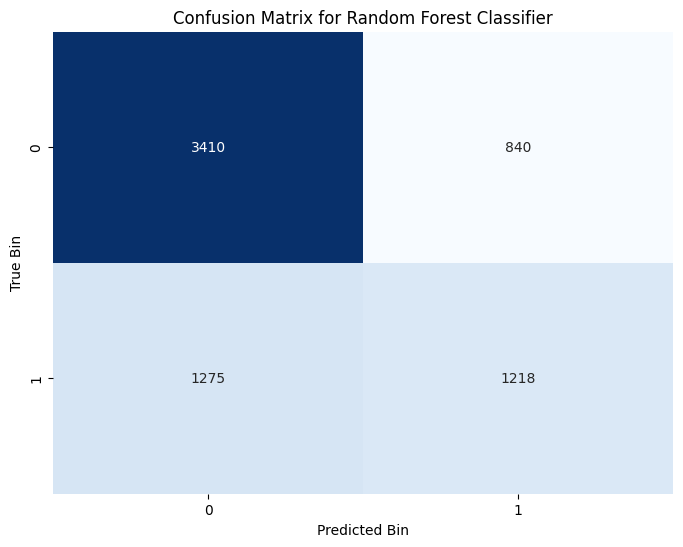

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Bin')
plt.ylabel('True Bin')
plt.show()